In [1]:
!nvidia-smi

Mon Oct  6 21:02:52 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:03:00.0 Off |                    0 |
| N/A   30C    P0             53W /  400W |       1MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear
from corner import corner

import tensorflow_probability.substrates.jax as tfp
import jax
from jax import random
import numpy as np
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import optax
tfd = tfp.distributions

/global/common/software/deepsrch/jax_gigalens_kernel/jax-gigalens/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                theta_E=tfd.LogNormal(jnp.log(1.25), 0.25),
                gamma=tfd.TruncatedNormal(2, 0.25, 1, 3),
                e1=tfd.Normal(0, 0.1),
                e2=tfd.Normal(0, 0.1),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05),
            )
        ),
        tfd.JointDistributionNamed(
            dict(gamma1=tfd.Normal(0, 0.05), gamma2=tfd.Normal(0, 0.05))
        ),
    ]
)
lens_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
                n_sersic=tfd.Uniform(2, 6),
                e1=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05),
                Ie=tfd.LogNormal(jnp.log(500.0), 0.3),
            )
        )
    ]
)

source_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.15),
                n_sersic=tfd.Uniform(0.5, 4),
                e1=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                center_x=tfd.Normal(0, 0.25),
                center_y=tfd.Normal(0, 0.25),
                Ie=tfd.LogNormal(jnp.log(150.0), 0.5),
            )
        )
    ]
)

prior = tfd.JointDistributionSequential(
    [lens_prior, lens_light_prior, source_light_prior]
)

In [4]:
kernel = np.load('./gigalens/assets/psf.npy').astype(np.float32) #added /gigalens
sim_config = SimulatorConfig(delta_pix=0.065, num_pix=60, supersample=2, kernel=kernel)
phys_model = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False)], [sersic.SersicEllipse(use_lstsq=False)])
lens_sim = LensSimulator(phys_model, sim_config, bs=1)
observed_img = np.load('./gigalens/assets/demo.npy') #added /gigalens
prob_model = ForwardProbModel(prior, observed_img, background_rms=0.2, exp_time=100)
model_seq = ModellingSequence(phys_model, prob_model, sim_config)

In [5]:
schedule_fn = optax.polynomial_schedule(init_value=-1e-2, end_value=-1e-2/3, 
                                      power=0.5, transition_steps=500)
opt = optax.chain(
  optax.scale_by_adam(),
  optax.scale_by_schedule(schedule_fn),
)
map_estimate = model_seq.MAP(opt, seed=0)

Chi-squared: 0.986: 100%|██████████| 350/350 [00:26<00:00, 13.17it/s] 


In [6]:
lps = prob_model.log_prob(LensSimulator(phys_model, sim_config, bs=500), map_estimate)[0]
best = map_estimate[jnp.argmax(lps)][jnp.newaxis,:]

In [7]:
schedule_fn = optax.polynomial_schedule(init_value=-1e-6, end_value=-3e-3, 
                                      power=2, transition_steps=300)
opt = optax.chain(
  optax.scale_by_adam(),
  optax.scale_by_schedule(schedule_fn),
)
qz, loss_hist = model_seq.SVI(best, opt, n_vi=1000, num_steps=1500)

ELBO: -73.073: 100%|██████████| 1500/1500 [01:28<00:00, 16.98it/s]


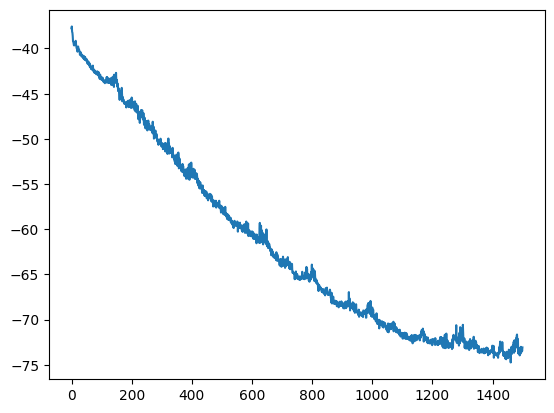

In [8]:
plt.plot(loss_hist)

In [9]:
samples = model_seq.HMC(qz, num_burnin_steps=250, num_results=750)

Sampling took 40.5s


In [10]:
rhat= tfp.mcmc.potential_scale_reduction(jnp.transpose(samples.all_states, (1,2,0,3)), independent_chain_ndims=2)

In [11]:
rhat

Array([1.0013523, 1.0098512, 1.0386888, 1.0337713, 1.0851177, 1.0250291,
       1.0561471, 1.0374805, 1.0165421, 1.0168781, 1.0029685, 1.0024147,
       1.0259176, 1.0025744, 1.0179007, 1.043753 , 1.0825545, 1.0063406,
       1.0751628, 1.0192026, 1.0045979, 1.0397749], dtype=float32)

In [12]:
smp = jnp.transpose(samples.all_states, (1, 2, 0, 3)).reshape((-1, 22))
smp_physical = prob_model.bij.forward(list(smp.T))

def get_corner_samples(physical, key):
    """
    Key tells you lens_mass (1), lens_light (2), or source_light (3)
    """
    return_list = []

    if key == 1:
        for i in physical[0][0].keys():
            return_list.append(physical[0][0][i])
        for j in physical[0][1].keys():
            return_list.append(physical[0][1][j])

    if key == 2:
        for i in physical[1][0].keys():
            return_list.append(physical[1][0][i])

    if key == 3:
        for i in physical[2][0].keys():
            return_list.append(physical[2][0][i])
            
    return np.stack(return_list).T

mass_samps = get_corner_samples(smp_physical, 1)

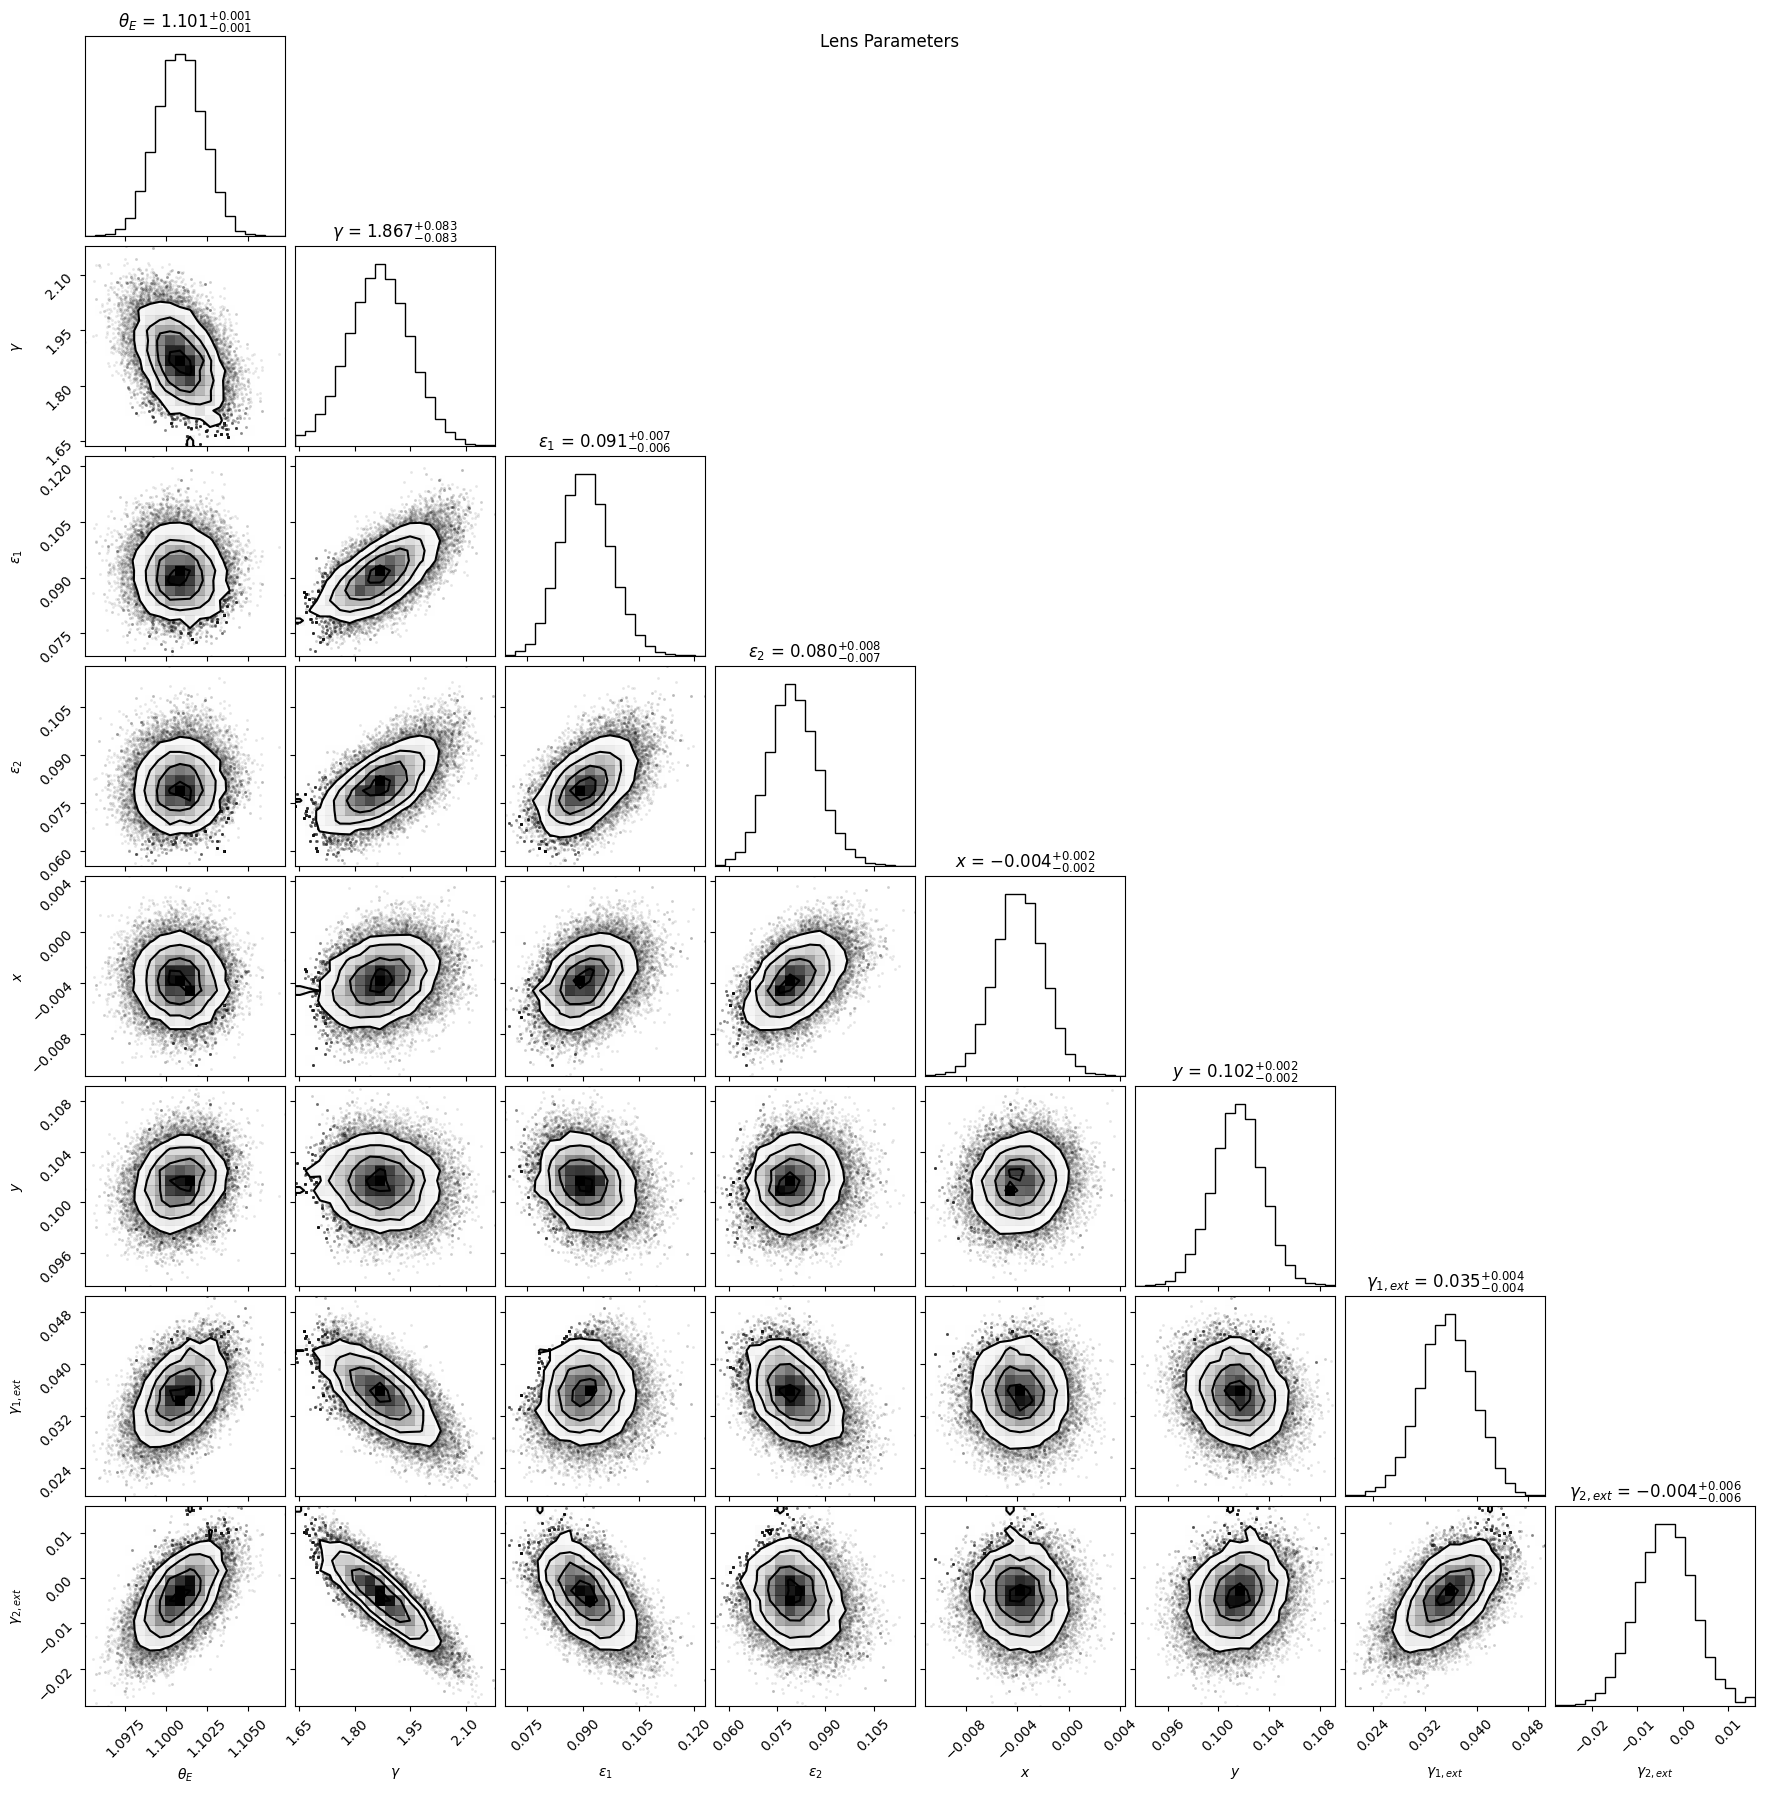

In [13]:
plt.style.use('default')

labels=[r'$\theta_E$', 
        r'$\gamma$', 
        r'$\epsilon_1$', 
        r'$\epsilon_2$', 
        r'$x$', r'$y$', 
        r'$\gamma_{1,ext}$', 
        r'$\gamma_{2,ext}$']

fig = corner(mass_samps, show_titles=True, title_fmt='.3f', labels=labels)
_ = fig.suptitle("Lens Parameters")